### DSMPC without Terminal Ingredients HALL AND ERDIN

Copyright (C) 2024, Alexander Erdin (aerdin@ethz.ch), ETH Zurich

This project is licensed under the MIT License.

#### Setup

In [1]:
# Reload scripts when executed
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from time import sleep
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib import colormaps
from params import DSMPCParams
from systems import LinearSystem
from controllers import EMPC
from controllers import CPEMPC

In [3]:
# Fix random seed and print options
np.random.seed(1)
np.set_printoptions(threshold=10000, linewidth=np.inf)

##### Load Parameters and Create System

In [60]:
params = DSMPCParams(verbose=True)
sys = LinearSystem(params.sys)

Agents: ['27', '142', '387', '1222', '1417', '2096', '2318', '2358', '3000', '3488']
Loaded data for 10 agents from 2019-05-02 00:00:00-04:00 to 2019-05-02 23:00:00-04:00
Cost matrices: Q shape: (24, 20, 20), R shape: (24, 20, 20), c shape: (24, 1, 20)
Constraint matrices: X shape: (24, 40, 20), c_x shape: (24, 40), U shape: (24, 62, 20), c_u shape: (24, 62)
Q is positive semi-definite for all times.
R is positive semi-definite for all times.


##### Initialize Controller

In [61]:
ctrl = CPEMPC(sys, params.ctrl)

#### Simulate System

##### Solve EMPC for Varying Initial States

In [62]:
# Setup simulation
num_steps = 48
x_0 = [np.tile(np.array([10/4*i, 15/4*i]), 10) for i in range(5)]
num_traj  = len(x_0)

# Allocate state and input trajectories
x = np.zeros((num_traj, num_steps+1, sys.n))
u = np.zeros((num_traj, num_steps,   sys.m))
x_ol = np.full((num_traj, params.ctrl.N+1, sys.n), np.nan)
u_ol = np.full((num_traj, params.ctrl.N,   sys.m), np.nan)

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(x_0, desc='Trajectories')):
    # Set initial state
    x[i,0,:] = xi_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg = ctrl.solve(x_0=x[i,t,:], t=t)
        if error_msg != None:
            raise Exception(error_msg)
        
        # Save open-loop trajectory
        if t == 0:
            x_ol[i,:] = sol_x.T
            u_ol[i,:] = sol_u.T

        # Propagate dynamics and save input
        u[i,t,:]   = sol_u[:,0]
        x[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))

        # Some debug information
        # tmp = np.abs(sol_x[:,1] - sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,)))
        # print('At time {0} Dynamics is {1} with diff: {2}'.format(t,np.all(tmp < 1E-5), np.max(tmp)))
        sleep(0.01)

Trajectories:   0%|          | 0/5 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

##### Solve EMPC for Varying Horizons

In [7]:
# Setup simulation
num_steps = 48
x_0 = np.zeros((sys.n,))
horizon = [6, 9, 12, 18, 24]
num_horizon = len(horizon)

# Allocate state and input trajectories
x2 = np.zeros((num_horizon, num_steps+1, sys.n))
u2 = np.zeros((num_horizon, num_steps,   sys.m))
x2_ol = np.full((num_horizon, max(horizon)+1, sys.n), np.nan)
u2_ol = np.full((num_horizon, max(horizon),   sys.m), np.nan)

# Simulate closed-loop system
for i, N in enumerate(tqdm(horizon, desc='Horizons')):
    # Load parameters and create system
    params2 = DSMPCParams(N=N)
    sys2 = LinearSystem(params2.sys)

    # Initialize controller
    ctrl2 = CPEMPC(sys2, params2.ctrl)

    # Set initial state
    x2[i,0,:] = x_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='   MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg = ctrl2.solve(x_0=x2[i,t,:], t=t, verbose=False)
        if error_msg != None:
            raise Exception(error_msg)
        
        # Save open-loop trajectory
        if t == 0:
            x2_ol[i,:N+1,:] = sol_x.T
            u2_ol[i,:N,:]   = sol_u.T

        # Propagate dynamics and save input
        u2[i,t,:]   = sol_u[:,0]
        x2[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

Horizons:   0%|          | 0/5 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

##### Approximate Infinite-Horizon Overtaking-Optimal Trajectory

In [58]:
# Load parameters and create system with a long horizon
params_inf = DSMPCParams(N=200)
sys_inf = LinearSystem(params_inf.sys)

# Initialize controller
ctrl_inf = CPEMPC(sys_inf, params_inf.ctrl)

# Solve EMPC problem with free initial state
sol_u, sol_x, error_msg = ctrl_inf.solve(t=0)
if error_msg != None:
    raise Exception(error_msg)
        
# Save trajectory
x_inf = sol_x.T
u_inf = sol_u.T

#### Plot Results

##### Sophie's Plot

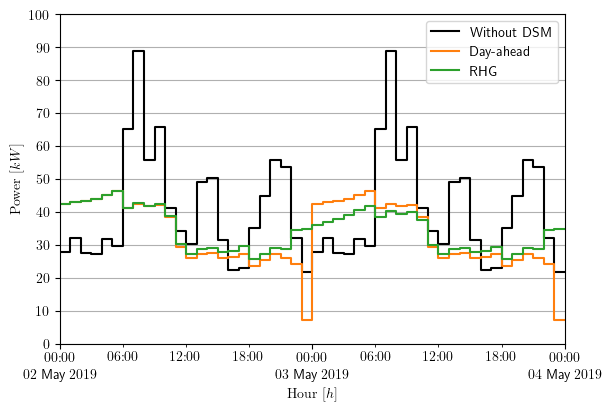

In [36]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Compute passive load without DSM
n_tile = int(num_steps/sys.T)
no_dsm = np.tile(params.ctrl.consumption.sum(axis=1) + params.ctrl.passive_load, n_tile)
no_dsm = np.hstack([no_dsm, no_dsm[-1]])

# Compute aggregate load
agg_load    = [u[i,:].sum(axis=1)    - np.tile(params.ctrl.solar.sum(axis=1), n_tile) + np.tile(params.ctrl.passive_load, n_tile) for i in range(num_traj)]
agg_load_ol = [np.tile(u_ol[i,:].sum(axis=1), 2) - np.tile(params.ctrl.solar.sum(axis=1), n_tile) + np.tile(params.ctrl.passive_load, n_tile) for i in range(num_traj)]
agg_load    = [np.hstack([agg_load[t],    agg_load[t][-1]]) for t in range(num_traj)]
agg_load_ol = [np.hstack([agg_load_ol[t], agg_load_ol[t][-1]]) for t in range(num_traj)]

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot passive load
axs.plot(dates, no_dsm, label='Without DSM', color='black', linestyle='-', drawstyle='steps-post')

# Plot trajectories
axs.plot(dates, agg_load_ol[0], label='Day-ahead', color='tab:orange', linestyle='-', drawstyle='steps-post')
axs.plot(dates, agg_load[0], label='RHG', color='tab:green', linestyle='-', drawstyle='steps-post')

# Add labels
axs.set_xlabel(r'\rmfamily{Hour} $[h]$')
axs.set_ylabel(r'\rmfamily{Power} $[kW]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
axs.yaxis.set_major_locator(ticker.MultipleLocator(base=10, offset=0))

# Set limits
axs.set_xlim([dates[0], dates[-1]])
axs.set_ylim([0, 100])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)

# Plot legend
axs.legend(loc='upper right')

# Export figure
fig.savefig("figures/figure_hall.pdf", bbox_inches='tight', pad_inches=0.1)

##### Convergence to the Overtaking-Optimal Trajectory

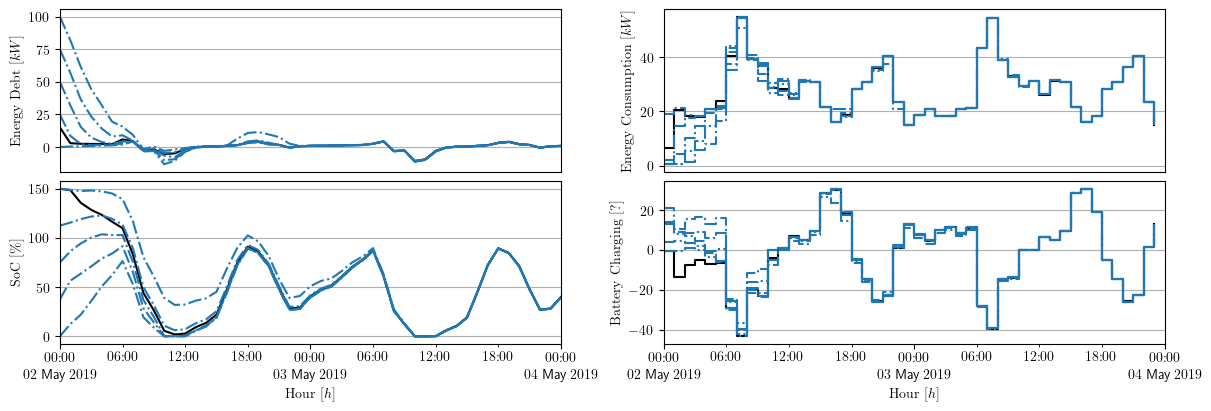

In [63]:
# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]
dates_ol = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(params.ctrl.N+1)]

# Compute accumulated states
x_acc = np.zeros((num_traj, num_steps+1, 2))
u_acc = np.zeros((num_traj, num_steps,   2))
x_acc_ol = np.zeros((num_traj, params.ctrl.N+1, 2))
u_acc_ol = np.zeros((num_traj, params.ctrl.N,   2))
for i in range(num_traj):
    x_acc[i,:,:] = np.vstack([x[i,:,0::2].sum(axis=1), x[i,:,1::2].sum(axis=1)]).T
    u_acc[i,:,:] = np.vstack([u[i,:,0::2].sum(axis=1), u[i,:,1::2].sum(axis=1)]).T
    x_acc_ol[i,:,:] = np.vstack([x_ol[i,:,0::2].sum(axis=1), x_ol[i,:,1::2].sum(axis=1)]).T
    u_acc_ol[i,:,:] = np.vstack([u_ol[i,:,0::2].sum(axis=1), u_ol[i,:,1::2].sum(axis=1)]).T
x_acc_inf = np.vstack([x_inf[:,0::2].sum(axis=1), x_inf[:,1::2].sum(axis=1)]).T
u_acc_inf = np.vstack([u_inf[:,0::2].sum(axis=1), u_inf[:,1::2].sum(axis=1)]).T

# Create figure
plt.rcParams['text.usetex'] = True
fig, axs = plt.subplots(2, 2, figsize=(12, 4), layout='constrained')

# Plot approximate overtaking-optimal trajectories
axs[0][0].plot(dates, x_acc_inf[:num_steps+1,0], color='black', linestyle='-')
axs[1][0].plot(dates, x_acc_inf[:num_steps+1,1], color='black', linestyle='-')
axs[0][1].plot(dates[:-1], u_acc_inf[:num_steps,0], color='black', linestyle='-', drawstyle='steps-post')
axs[1][1].plot(dates[:-1], u_acc_inf[:num_steps,1], color='black', linestyle='-', drawstyle='steps-post')

# Plot trajectories
for i in range(num_traj):
    axs[0][0].plot(dates, x_acc[i,:,0], color='tab:blue', linestyle='-.')
    axs[1][0].plot(dates, x_acc[i,:,1], color='tab:blue', linestyle='-.')
    axs[0][1].plot(dates[:-1], u_acc[i,:,0], color='tab:blue', linestyle='-.', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], u_acc[i,:,1], color='tab:blue', linestyle='-.', drawstyle='steps-post')


# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[1][0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[0][1].set_ylabel(r'\rmfamily{Energy Consumption} $[kW]$')
axs[1][1].set_ylabel(r'\rmfamily{Battery Charging} $[?]$')
axs[1][0].set_xlabel(r'\rmfamily{Hour} $[h]$')
axs[1][1].set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

for i, ax in enumerate(axs.flatten()):
    # Set axis limits
    ax.set_xlim([dates[0], dates[-1]])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Export figure
fig.savefig("figures/figure_asymptotic_convergence.pdf", bbox_inches='tight', pad_inches=0.1)

##### Turnpike Plots

We decided to plot accumulated states and inputs to demonstrate the turnpike property as we have a multidimensional system containing multiple agents $v$. Hence the accumulated states are simple sums across all agents given by
\begin{equation}
    \bar{\zeta}_t = \sum_{v \in \mathcal{A}} \zeta_t^v, \qquad \bar{q}_t = \sum_{v \in \mathcal{A}} q_t^v
\end{equation}
with $\bar{x}_t = (\bar{\zeta}_t, \bar{q}_t)$ being the accumulated state vector. The accumulated inputs $\bar{u}_t$ are defined analogously.

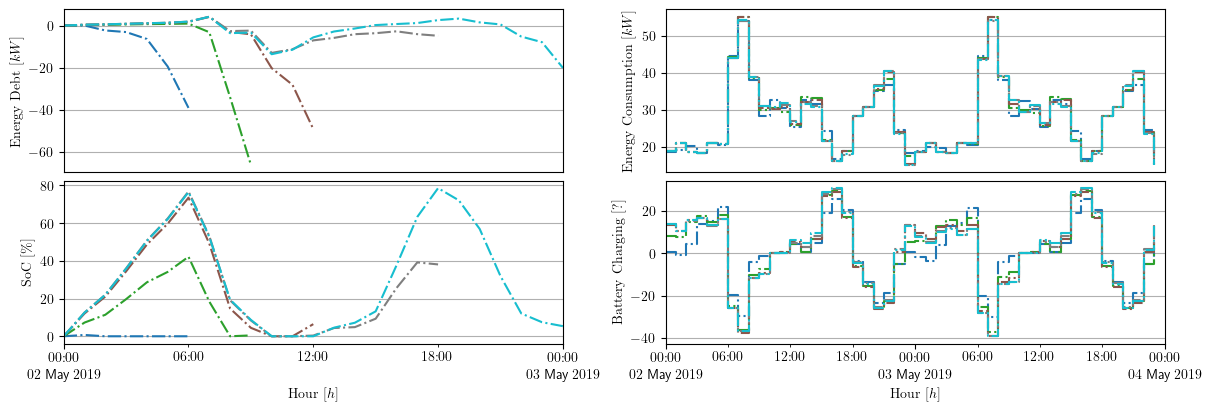

In [11]:
# Create time vector
dates = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]
dates_ol = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(max(horizon)+1)]

# Compute accumulated states
x_acc = np.zeros((num_horizon, num_steps+1, 2))
u_acc = np.zeros((num_horizon, num_steps,   2))
x_acc_ol = np.zeros((num_horizon, max(horizon)+1, 2))
u_acc_ol = np.zeros((num_horizon, max(horizon),   2))
for i, _ in enumerate(horizon):
    x_acc[i,:,:] = np.vstack([x2[i,:,0::2].sum(axis=1), x2[i,:,1::2].sum(axis=1)]).T
    u_acc[i,:,:] = np.vstack([u2[i,:,0::2].sum(axis=1), u2[i,:,1::2].sum(axis=1)]).T
    x_acc_ol[i,:,:] = np.vstack([x2_ol[i,:,0::2].sum(axis=1), x2_ol[i,:,1::2].sum(axis=1)]).T
    u_acc_ol[i,:,:] = np.vstack([u2_ol[i,:,0::2].sum(axis=1), u2_ol[i,:,1::2].sum(axis=1)]).T

# Create colormap
colors = colormaps['tab10'].resampled(num_horizon)

# Create figure
plt.rcParams['text.usetex'] = True
fig, axs = plt.subplots(2, 2, figsize=(12, 4), layout='constrained')

# Plot trajectories
for i, _ in enumerate(horizon):
    axs[0][0].plot(dates_ol, x_acc_ol[i,:,0], color=colors(i), linestyle='-.')
    axs[1][0].plot(dates_ol, x_acc_ol[i,:,1], color=colors(i), linestyle='-.')
    axs[0][1].plot(dates[:-1], u_acc[i,:,0], color=colors(i), linestyle='-.', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], u_acc[i,:,1], color=colors(i), linestyle='-.', drawstyle='steps-post')

# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[1][0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[0][1].set_ylabel(r'\rmfamily{Energy Consumption} $[kW]$')
axs[1][1].set_ylabel(r'\rmfamily{Battery Charging} $[?]$')
axs[1][0].set_xlabel(r'\rmfamily{Hour} $[h]$')
axs[1][1].set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M \\ %d %b %Y'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

for i, ax in enumerate(axs.flatten()):
    # Set axis limits
    if i % 2 != 0:
        ax.set_xlim([dates[0], dates[-1]])
    else:
        ax.set_xlim([dates[0], dates_ol[-1]])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Export figure
fig.savefig("figures/figure_turnpike1.pdf", bbox_inches='tight', pad_inches=0.1)

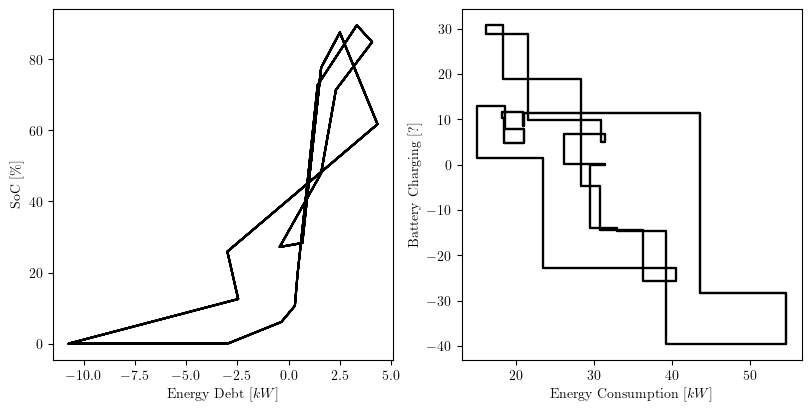

In [ ]:
# Create figure
plt.rcParams['text.usetex'] = True
fig, axs = plt.subplots(1, 2, figsize=(8, 4), layout='constrained')

# Plot trajectories
axs[0].plot(x_acc_inf[48:-48,0], x_acc_inf[48:-48,1], color='black', linestyle='-')
axs[1].plot(u_acc_inf[48:-48,0], u_acc_inf[48:-48,1], color='black', linestyle='-', drawstyle='steps-post')
# for i, _ in enumerate(horizon):
#     axs[0].plot(x_acc_ol[i,:,0], x_acc_ol[i,:,1], color='tab:blue', linestyle='-.')
#     axs[1].plot(u_acc[i,:,0], u_acc[i,:,1], color='tab:blue', linestyle='-.', drawstyle='steps-post')

# Add labels
axs[0].set_xlabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[1].set_xlabel(r'\rmfamily{Energy Consumption} $[kW]$')
axs[1].set_ylabel(r'\rmfamily{Battery Charging} $[?]$');

# Export figure
fig.savefig("figures/figure_turnpike2.pdf", bbox_inches='tight', pad_inches=0.1)